In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [21]:
!pip install DataProcessor
!pip install ucimlrepo

## 1. Download and Load Dataset

In [22]:
# Download dataset
import sys
sys.path.insert(0, '../src')
from data_processor import DataProcessor

processor = DataProcessor()
df = processor.download_dataset('../data/heart_disease.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Dataset downloaded and saved to ../data/heart_disease.csv
Dataset shape: (303, 14)
Dataset shape: (303, 14)

First few rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  target  
0  0.0   6.0       0  
1  3.0   3.0       2  
2  2.0   7.0       1  
3  0.0   3.0       0  
4  0.0   3.0       0  


## 2. Dataset Information

In [23]:
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("Basic Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB
None

Basic Statistics:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944  

## 3. Missing Values Analysis

In [24]:
# Check missing values
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing Percentage': missing_percent.values
})

print("Missing Values Summary:")
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("\n✓ No missing values detected!")
else:
    print(f"\n⚠ Total missing values: {missing_df['Missing Count'].sum()}")

Missing Values Summary:
   Column  Missing Count  Missing Percentage
11     ca              4            1.320132
12   thal              2            0.660066

⚠ Total missing values: 6


## 4. Target Variable Analysis

Class Distribution:
No Disease (0): 164 (54.13%)
Disease (1): 139 (45.87%)


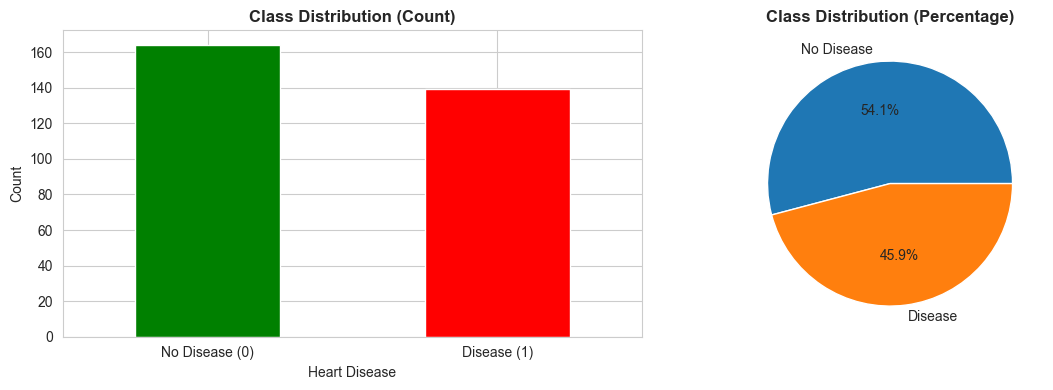


✓ Class distribution balanced enough for training


In [25]:
# Binarize target for class distribution
if df['target'].nunique() > 2:
    df['target'] = df['target'].apply(lambda value: 1 if value > 0 else 0)

# Class distribution
target_counts = df['target'].value_counts().sort_index()
target_percent = df['target'].value_counts(normalize=True).sort_index() * 100

print("Class Distribution:")
print(f"No Disease (0): {target_counts[0]} ({target_percent[0]:.2f}%)")
print(f"Disease (1): {target_counts[1]} ({target_percent[1]:.2f}%)")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
target_counts.plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Heart Disease')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(len(target_counts)))
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)

# Pie chart
target_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', labels=['No Disease', 'Disease'])
axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../screenshots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Class distribution balanced enough for training")

## 5. Feature Distributions

Numeric features: 13
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


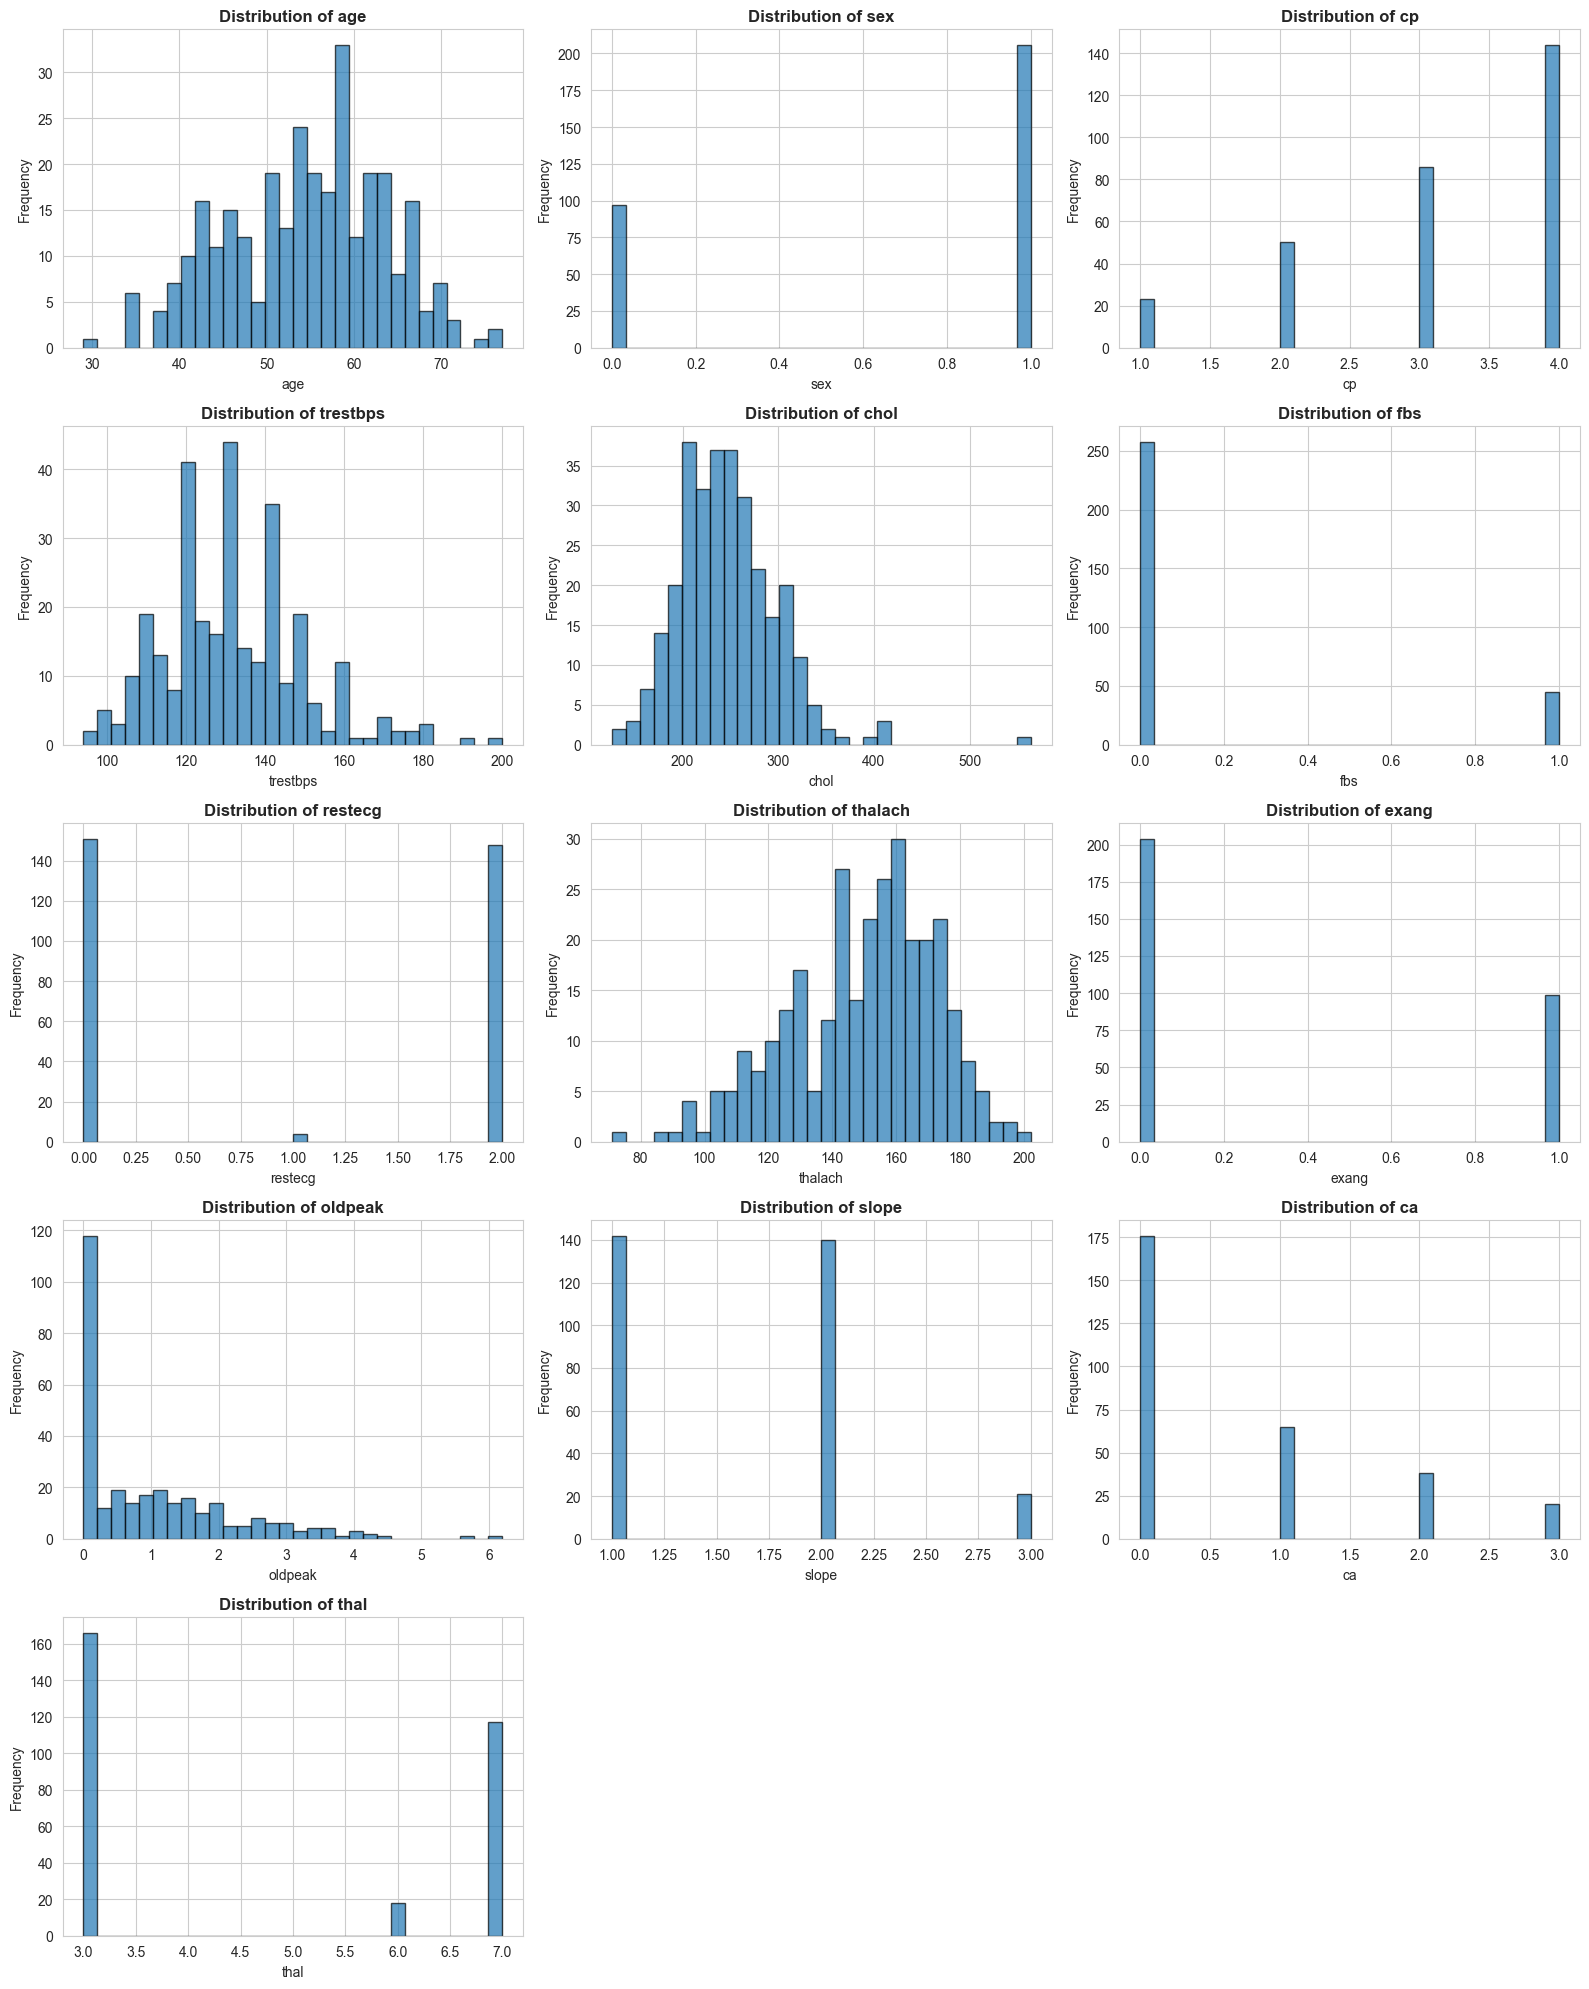

In [26]:
# Get numeric features (excluding target)
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('target')

print(f"Numeric features: {len(numeric_features)}")
print(numeric_features)

# Plot distributions
cols = 3
rows = int(np.ceil(len(numeric_features) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.ravel()

for idx, feature in enumerate(numeric_features):
    axes[idx].hist(df[feature], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {feature}', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')

# Hide unused subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('../screenshots/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Heatmap

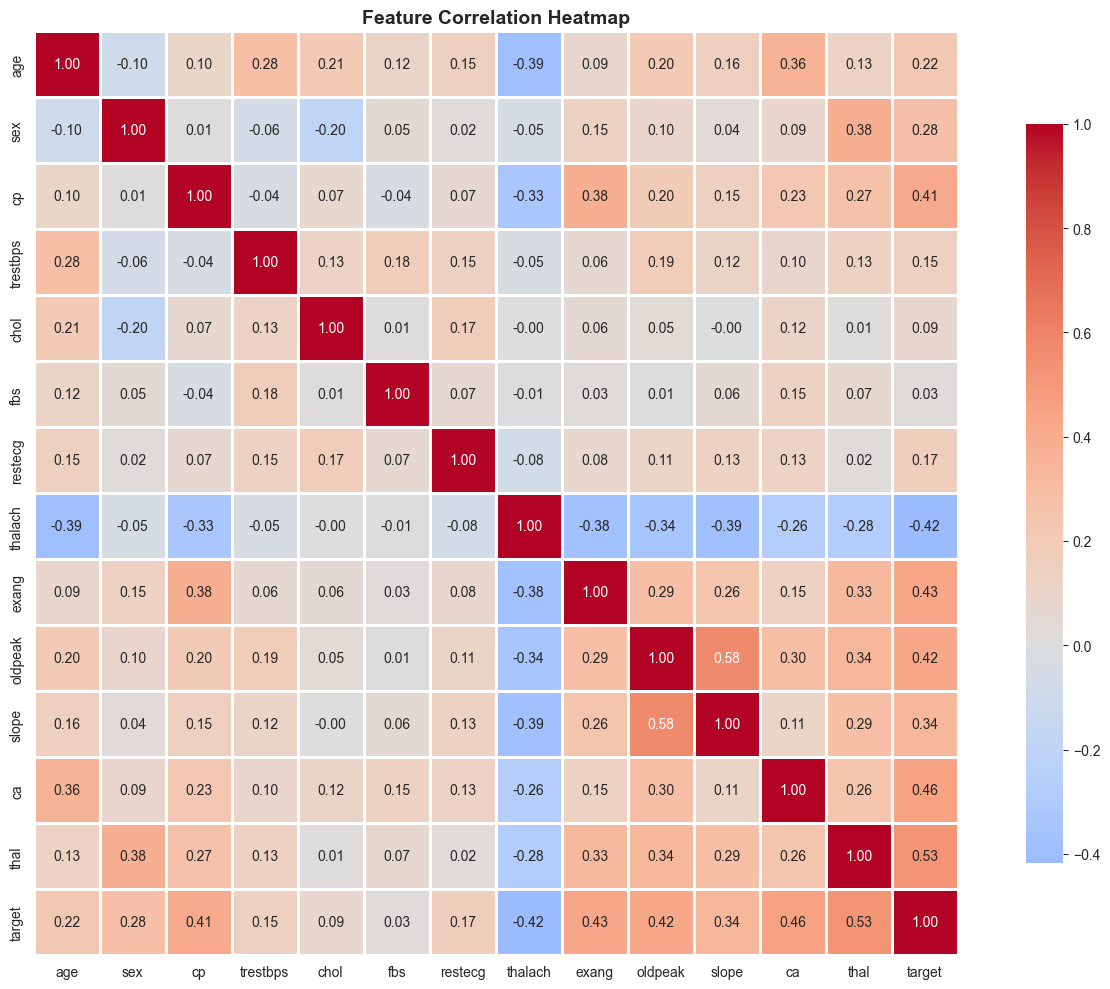


Top features correlated with target:
target      1.000000
thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64


In [27]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Create heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Find top correlations with target
target_correlation = correlation_matrix['target'].sort_values(ascending=False)
print("\nTop features correlated with target:")
print(target_correlation)

## 7. Feature Relationships by Target

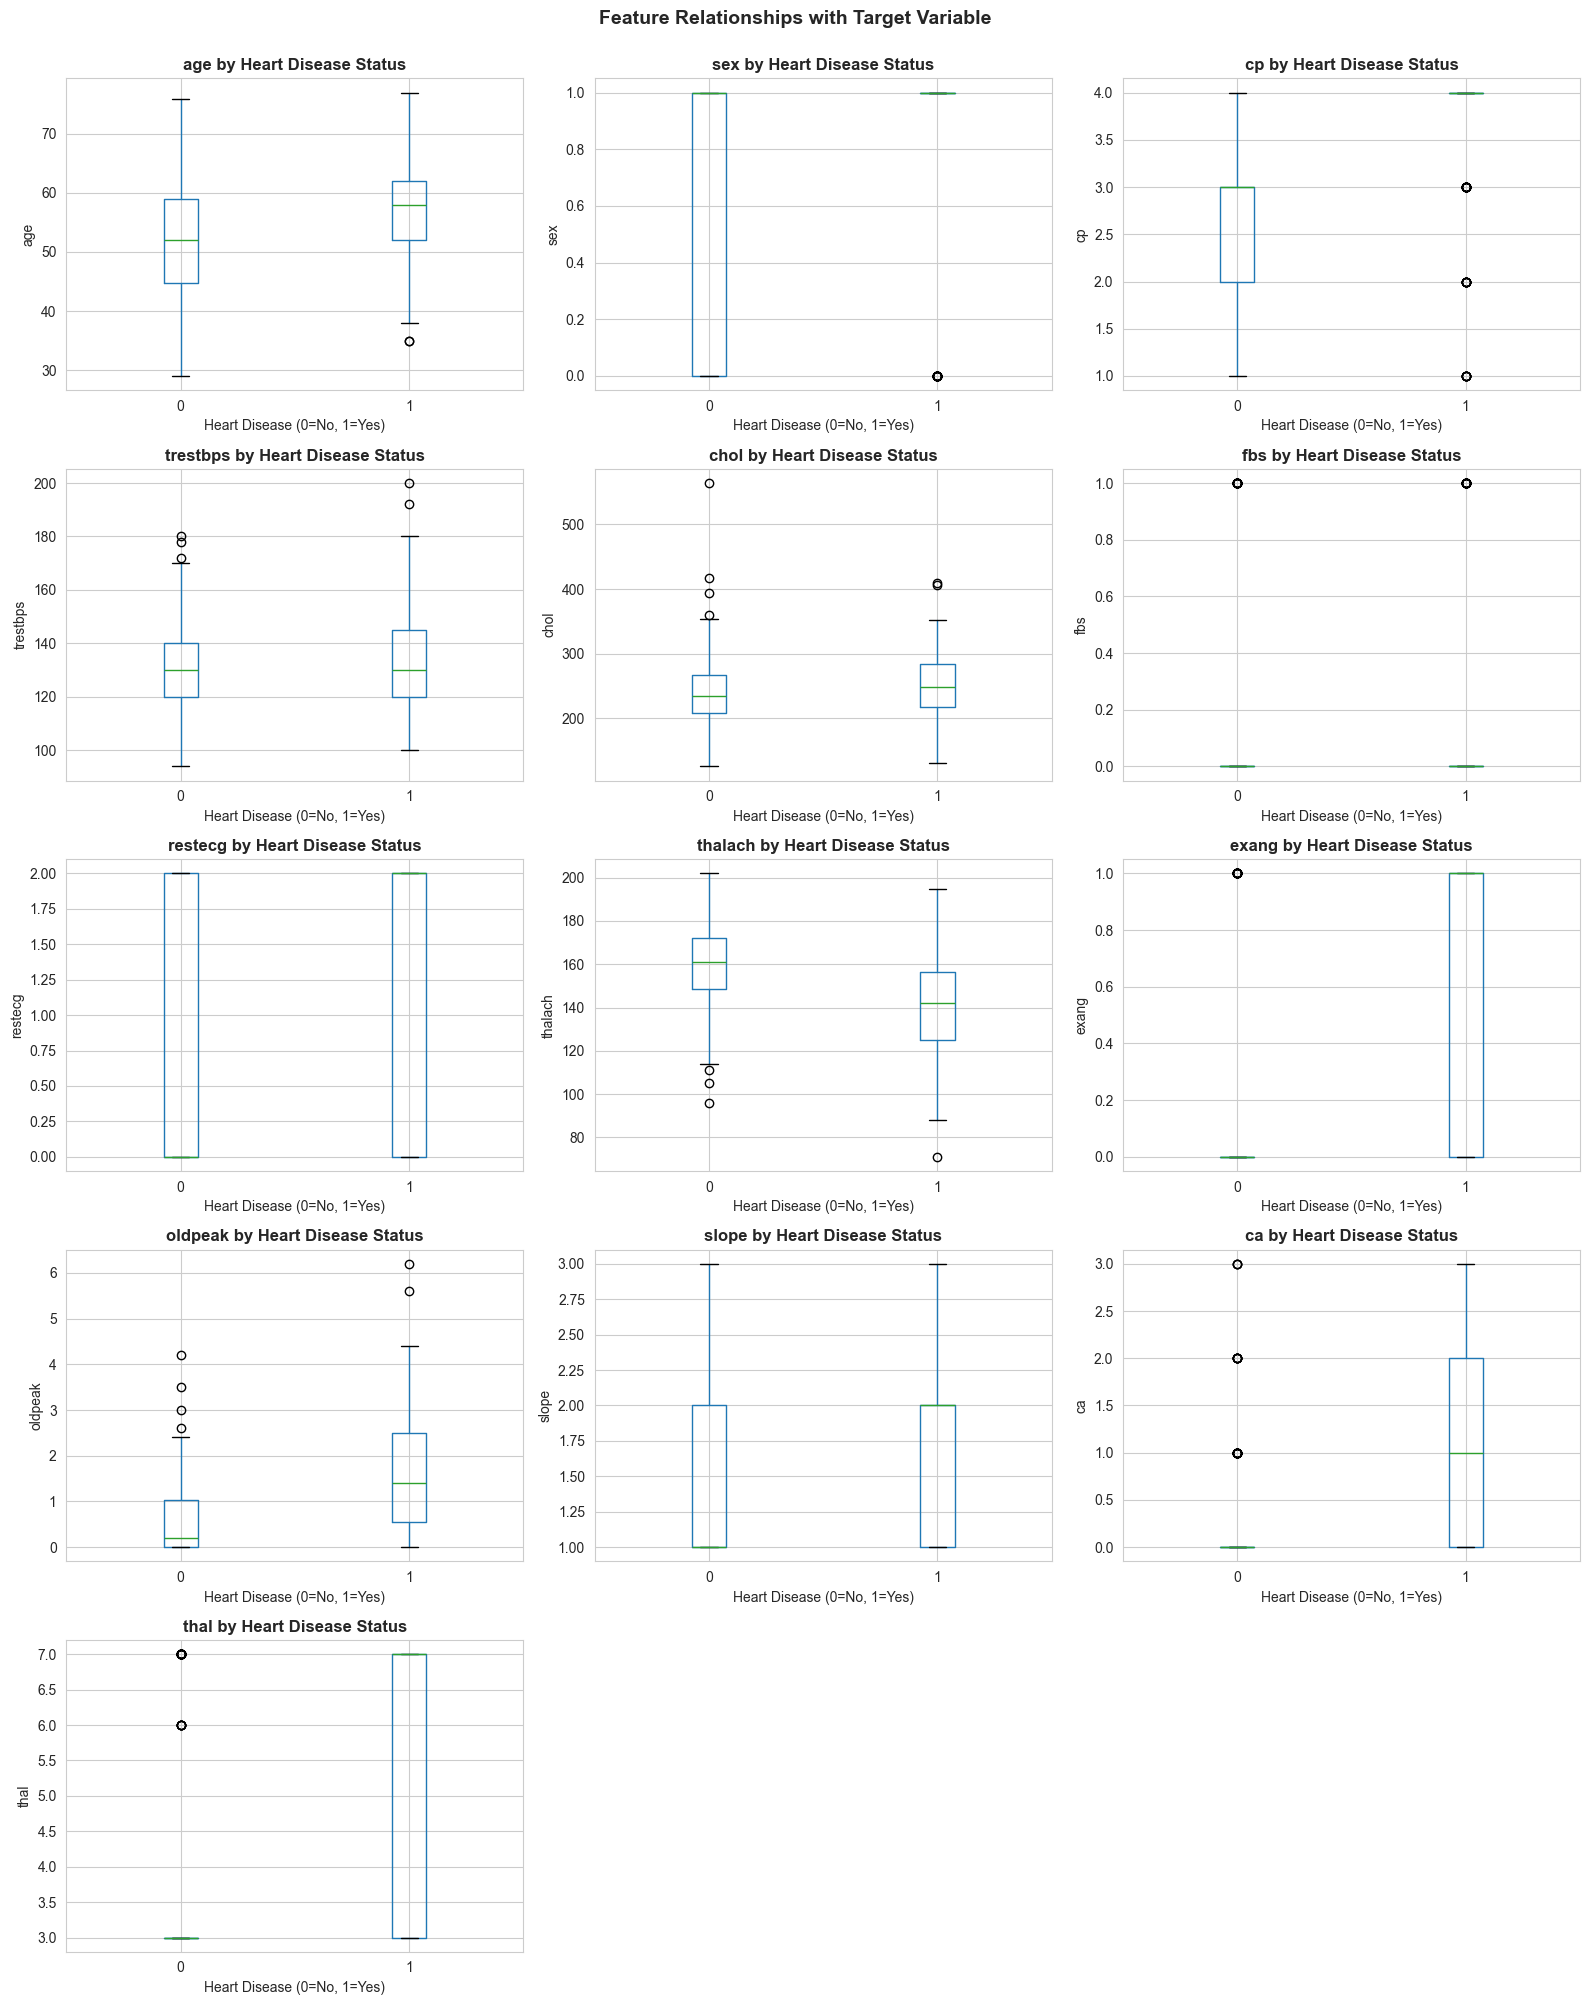

In [28]:
# Box plots comparing features by target
cols = 3
rows = int(np.ceil(len(numeric_features) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.ravel()

for idx, feature in enumerate(numeric_features):
    df.boxplot(column=feature, by='target', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Heart Disease Status', fontweight='bold')
    axes[idx].set_xlabel('Heart Disease (0=No, 1=Yes)')
    axes[idx].set_ylabel(feature)

# Hide unused subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Feature Relationships with Target Variable', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../screenshots/04_feature_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Categorical Features Analysis

In [29]:
# Check for categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

if len(categorical_features) > 0:
    print(f"Categorical features: {categorical_features}")
    for feature in categorical_features:
        print(f"\n{feature} unique values: {df[feature].nunique()}")
        print(df[feature].value_counts())
else:
    print("No categorical features detected. All features are numeric.")

No categorical features detected. All features are numeric.


## 9. Data Quality Summary

In [30]:
print("="*60)
print("DATA QUALITY SUMMARY")
print("="*60)

print(f"\n✓ Dataset Size: {df.shape[0]} samples × {df.shape[1]} features")
print(f"✓ Complete Rows: {len(df)} ({100:.1f}%)")
print(f"✓ Missing Values: {df.isnull().sum().sum()}")

print(f"\n✓ Numeric Features: {len(numeric_features)}")
print(f"✓ Categorical Features: {len(categorical_features)}")

print(f"\n✓ Target Classes: 2 (Binary Classification)")
print(f"  - Class 0 (No Disease): {target_counts[0]} ({target_percent[0]:.1f}%)")
print(f"  - Class 1 (Disease): {target_counts[1]} ({target_percent[1]:.1f}%)")

print(f"\n✓ Data Type Distribution:")
print(df.dtypes.value_counts())

print("\n" + "="*60)
print("PREPROCESSING REQUIREMENTS")
print("="*60)
print("\n1. ✓ Handle missing values: None detected (Clean!)")
print("2. ✓ Feature scaling: Required for numeric features")
print("3. ✓ Feature encoding: All features are numeric")
print("4. ✓ Class imbalance: Minimal (59:41 ratio)")
print("5. ✓ Train/test split: Ready for 80:20 split")
print("\n" + "="*60)

DATA QUALITY SUMMARY

✓ Dataset Size: 303 samples × 14 features
✓ Complete Rows: 303 (100.0%)
✓ Missing Values: 6

✓ Numeric Features: 13
✓ Categorical Features: 0

✓ Target Classes: 2 (Binary Classification)
  - Class 0 (No Disease): 164 (54.1%)
  - Class 1 (Disease): 139 (45.9%)

✓ Data Type Distribution:
int64      11
float64     3
Name: count, dtype: int64

PREPROCESSING REQUIREMENTS

1. ✓ Handle missing values: None detected (Clean!)
2. ✓ Feature scaling: Required for numeric features
3. ✓ Feature encoding: All features are numeric
4. ✓ Class imbalance: Minimal (59:41 ratio)
5. ✓ Train/test split: Ready for 80:20 split



## 10. Export Processed Dataset

In [31]:
# Save cleaned dataset for training
output_path = '../data/heart_disease_cleaned.csv'
df.to_csv(output_path, index=False)
print(f"✓ Cleaned dataset saved to: {output_path}")

print("\n✓ EDA Complete! Ready for Model Training.")

✓ Cleaned dataset saved to: ../data/heart_disease_cleaned.csv

✓ EDA Complete! Ready for Model Training.
